# Visualización de partículas en \(x,y,z\)

Este notebook lee las posiciones finales de las partículas escritas por el código Fortran y genera gráficos de la distribución espacial.

Por defecto lee:

```text
output/gc_txt_particles_final.dat
```

El archivo esperado tiene columnas:

```text
# id x y z vpar mu active
```

La última columna, `active`, suele estar escrita como `T` o `F`, por lo que el notebook lee sólo las columnas numéricas.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "legend.fontsize": 12,
})

## Configuración

Ejecutar este notebook desde el directorio principal del código:

```bash
cd guiding_center_txt
jupyter notebook
```

Si el notebook queda dentro de `scripts/`, cambiar `data_dir = Path("../output")`.

In [2]:
# Si ejecutás el notebook desde el directorio principal del código:
data_dir = Path("../output")

# Si lo ejecutás desde la carpeta scripts/, usar:
# data_dir = Path("../output")

prefix = "gc_txt"

particles_file = data_dir / f"{prefix}_particles_final.dat"

print("Particles file:", particles_file)
print("Existe:", particles_file.exists())

Particles file: ../output/gc_txt_particles_final.dat
Existe: True


## Leer partículas

Se leen las columnas numéricas:

\[
{\rm id},\quad x,\quad y,\quad z,\quad v_\parallel,\quad \mu.
\]

La columna lógica `active`, escrita como `T` o `F`, se ignora en esta lectura básica.

In [3]:
if not particles_file.exists():
    raise FileNotFoundError(
        f"No encontré {particles_file}. "
        "Primero corré ./gc_particles desde el directorio principal."
    )

# Formato esperado:
# id x y z vpar mu active
# Leemos sólo las primeras seis columnas numéricas.
data = np.loadtxt(particles_file, comments="#", usecols=(0, 1, 2, 3, 4, 5))

if data.ndim == 1:
    data = data.reshape(1, -1)

pid  = data[:, 0].astype(int)
x    = data[:, 1]
y    = data[:, 2]
z    = data[:, 3]
vpar = data[:, 4]
mu   = data[:, 5]

print(f"Número de partículas leídas: {len(x)}")
print(f"x: min={x.min():.6e}, max={x.max():.6e}")
print(f"y: min={y.min():.6e}, max={y.max():.6e}")
print(f"z: min={z.min():.6e}, max={z.max():.6e}")
print(f"vpar: min={vpar.min():.6e}, mean={vpar.mean():.6e}, max={vpar.max():.6e}")
print(f"mu:   min={mu.min():.6e}, mean={mu.mean():.6e}, max={mu.max():.6e}")

Número de partículas leídas: 1000
x: min=4.019255e-01, max=5.977961e-01
y: min=0.000000e+00, max=0.000000e+00
z: min=1.725356e-03, max=9.990312e-01
vpar: min=-9.814731e+05, mean=-3.816307e+03, max=8.936309e+05
mu:   min=3.726712e-23, mean=6.468256e-20, max=4.328610e-19


## Submuestreo para graficar

Si hay muchas partículas, graficar todas puede ser lento. Esta celda toma una muestra aleatoria de tamaño `nplot`.

In [4]:
nplot = 20000

rng = np.random.default_rng(1234)

if len(x) > nplot:
    idx = rng.choice(len(x), size=nplot, replace=False)
else:
    idx = np.arange(len(x))

xp = x[idx]
yp = y[idx]
zp = z[idx]
vpar_p = vpar[idx]
mu_p = mu[idx]

print(f"Partículas graficadas: {len(idx)}")

Partículas graficadas: 1000


## Gráfico 3D de partículas

Cada punto representa la posición final de un centro guía.

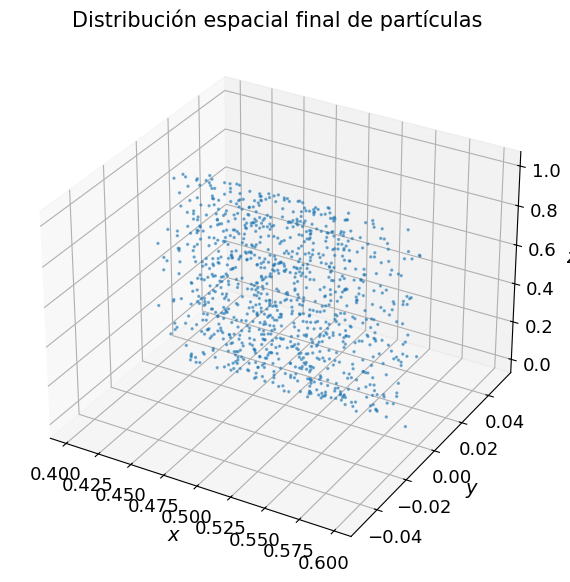

In [5]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(xp, yp, zp, s=2, alpha=0.5)

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_zlabel(r"$z$")
ax.set_title("Distribución espacial final de partículas")

plt.tight_layout()
plt.show()

## Gráfico 3D coloreado por \(v_\parallel\)

Este gráfico ayuda a ver si existe una correlación espacial con la velocidad paralela.

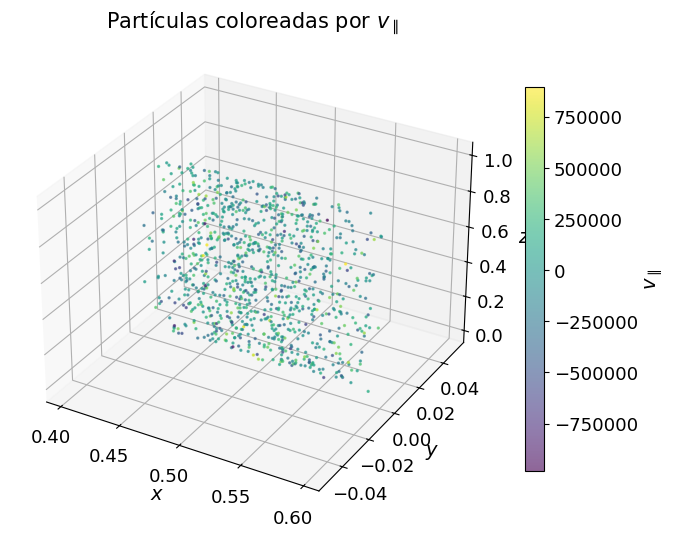

In [6]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(xp, yp, zp, c=vpar_p, s=2, alpha=0.6)

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_zlabel(r"$z$")
ax.set_title(r"Partículas coloreadas por $v_\parallel$")

cbar = fig.colorbar(sc, ax=ax, shrink=0.7)
cbar.set_label(r"$v_\parallel$")

plt.tight_layout()
plt.show()

## Proyección \(x-y\)

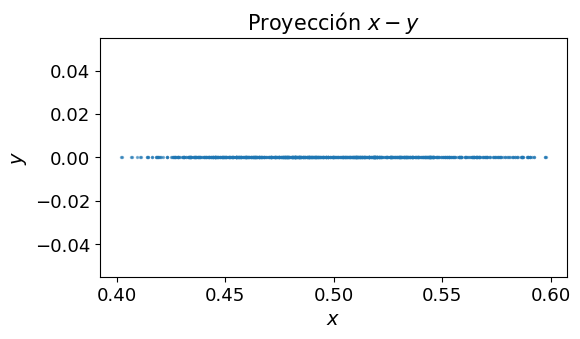

In [7]:
plt.figure(figsize=(6, 5))
plt.scatter(xp, yp, s=2, alpha=0.5)
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title(r"Proyección $x-y$")
plt.gca().set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

## Proyección \(x-z\)

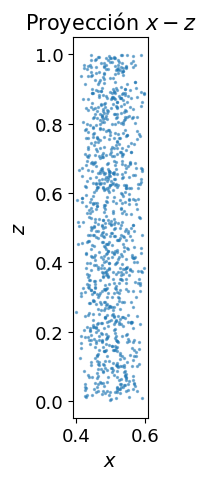

In [8]:
plt.figure(figsize=(6, 5))
plt.scatter(xp, zp, s=2, alpha=0.5)
plt.xlabel(r"$x$")
plt.ylabel(r"$z$")
plt.title(r"Proyección $x-z$")
plt.gca().set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

## Proyección \(y-z\)

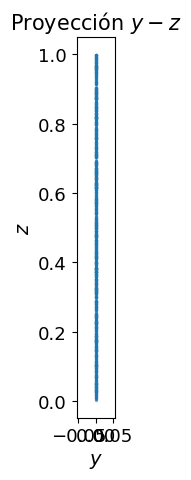

In [9]:
plt.figure(figsize=(6, 5))
plt.scatter(yp, zp, s=2, alpha=0.5)
plt.xlabel(r"$y$")
plt.ylabel(r"$z$")
plt.title(r"Proyección $y-z$")
plt.gca().set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

## Histogramas 1D de posiciones

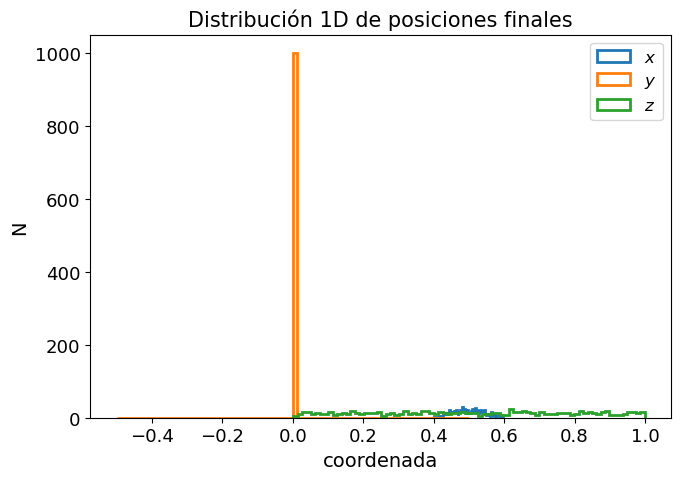

In [10]:
nbins = 80

plt.figure(figsize=(7, 5))
plt.hist(x, bins=nbins, histtype="step", linewidth=2, label=r"$x$")
plt.hist(y, bins=nbins, histtype="step", linewidth=2, label=r"$y$")
plt.hist(z, bins=nbins, histtype="step", linewidth=2, label=r"$z$")
plt.xlabel("coordenada")
plt.ylabel("N")
plt.title("Distribución 1D de posiciones finales")
plt.legend()
plt.tight_layout()
plt.show()

## Mapas 2D de densidad proyectada

Si hay muchas partículas, los histogramas 2D son más informativos que los scatter plots.

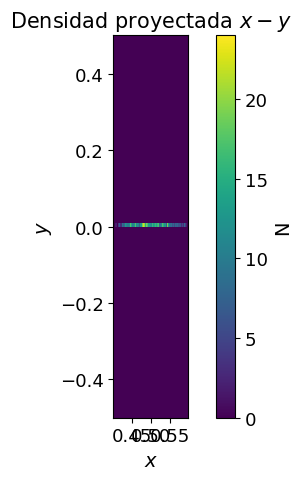

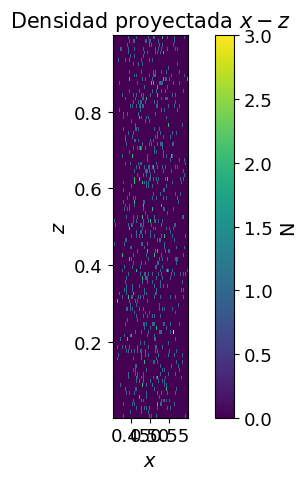

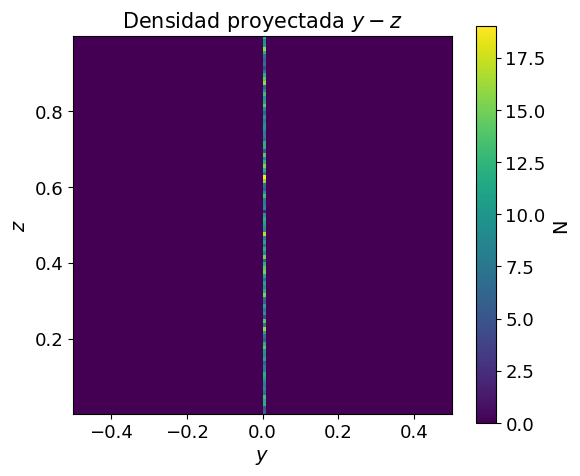

In [11]:
nbins2d = 100

plt.figure(figsize=(6, 5))
plt.hist2d(x, y, bins=nbins2d)
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title(r"Densidad proyectada $x-y$")
plt.gca().set_aspect("equal", adjustable="box")
plt.colorbar(label="N")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.hist2d(x, z, bins=nbins2d)
plt.xlabel(r"$x$")
plt.ylabel(r"$z$")
plt.title(r"Densidad proyectada $x-z$")
plt.gca().set_aspect("equal", adjustable="box")
plt.colorbar(label="N")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.hist2d(y, z, bins=nbins2d)
plt.xlabel(r"$y$")
plt.ylabel(r"$z$")
plt.title(r"Densidad proyectada $y-z$")
plt.gca().set_aspect("equal", adjustable="box")
plt.colorbar(label="N")
plt.tight_layout()
plt.show()

## Guardar figuras

Esta celda guarda un gráfico 3D y las tres proyecciones.

In [12]:
fig_dir = data_dir
fig_dir.mkdir(exist_ok=True)

fig3d = fig_dir / f"{prefix}_particles_xyz_3d.png"
figxy = fig_dir / f"{prefix}_particles_xy.png"
figxz = fig_dir / f"{prefix}_particles_xz.png"
figyz = fig_dir / f"{prefix}_particles_yz.png"

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(xp, yp, zp, s=2, alpha=0.5)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_zlabel(r"$z$")
ax.set_title("Distribución espacial final de partículas")
fig.tight_layout()
fig.savefig(fig3d, dpi=200)
plt.close(fig)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(xp, yp, s=2, alpha=0.5)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_title(r"Proyección $x-y$")
ax.set_aspect("equal", adjustable="box")
fig.tight_layout()
fig.savefig(figxy, dpi=200)
plt.close(fig)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(xp, zp, s=2, alpha=0.5)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$z$")
ax.set_title(r"Proyección $x-z$")
ax.set_aspect("equal", adjustable="box")
fig.tight_layout()
fig.savefig(figxz, dpi=200)
plt.close(fig)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(yp, zp, s=2, alpha=0.5)
ax.set_xlabel(r"$y$")
ax.set_ylabel(r"$z$")
ax.set_title(r"Proyección $y-z$")
ax.set_aspect("equal", adjustable="box")
fig.tight_layout()
fig.savefig(figyz, dpi=200)
plt.close(fig)

print("Figuras guardadas:")
print(fig3d)
print(figxy)
print(figxz)
print(figyz)

Figuras guardadas:
../output/gc_txt_particles_xyz_3d.png
../output/gc_txt_particles_xy.png
../output/gc_txt_particles_xz.png
../output/gc_txt_particles_yz.png
